# DCGAN for Human Face Generation

## 1. Project Overview
This notebook implements a **Deep Convolutional Generative Adversarial Network (DCGAN)** using PyTorch. The goal is to generate new, synthetic 64x64 RGB images of human faces from random noise.

### Model Architecture
The architecture follows standard DCGAN guidelines to ensure stable training:
* **Generator:** Takes a latent vector ($z$) of size 100 and upsamples it using Transposed Convolutions (`ConvTranspose2d`) and Batch Normalization to produce a 64x64 image. It uses `ReLU` activations and a final `Tanh` function to map pixel values between [-1, 1].
* **Discriminator:** A binary classifier that uses Strided Convolutions (`Conv2d`) to downsample images and distinguish between real photos and fake ones generated by the model. It uses `LeakyReLU` and `Sigmoid` activation.

---

## 2. Training & Hardware Constraints
**Current Status:**
Due to hardware memory limitations on the local machine, this specific run was restricted to **30 epochs**.

**Expected Performance:**
* **At 30 Epochs:** The model begins to learn the general distribution of skin tones, head shapes, and hair, but facial features (eyes, nose, mouth) may still appear blurry or distorted.
* **At 200 Epochs:** With the full training schedule originally intended, the Generator and Discriminator would reach a better equilibrium. This would result in much sharper, more realistic human faces with distinct features and fewer artifacts.

---

## 3. Future Improvements
In future iterations, we plan to:
1.  **Extended Training:** Run the training for the full 200+ epochs on a machine with higher GPU VRAM (e.g., using cloud resources like Colab Pro or AWS).
2.  **Advanced Architectures:** Explore more advanced models such as **StyleGAN** or **ProGAN** for high-resolution generation.
3.  **Stabilization Techniques:** Implement techniques like label smoothing or spectral normalization to further stabilize training and prevent mode collapse.

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
LR = 0.0002            # Learning rate 
BETA1 = 0.5            # Beta1 for Adam 
BATCH_SIZE = 128       # Batch size
IMAGE_SIZE = 64        # 64x64 for better face quality
CHANNELS = 3           # Color images
Z_DIM = 100            # Latent vector size 
NUM_EPOCHS = 200       # Number of training epochs

Using device: cuda


In [ ]:
# specific folder path
#  images are in: ./my_faces_dataset/images/*.jpg
DATA_PATH = './dataset' 

# Create the directory if it doesn't exist 
if not os.path.exists(DATA_PATH):
    os.makedirs(os.path.join(DATA_PATH, 'my_faces_dataset'))
    print(f"Created folder {DATA_PATH}. Please put  images in the 'my_faces_dataset' subfolder!")

# Define transforms: Resize -> Tensor -> Normalize (-1 to 1)
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Load dataset
try:
    dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"Loaded {len(dataset)} images.")
except:
    print("No images found. Please ensure you have images in the folder structure: root/class/image.jpg")

Loaded 7219 images.


In [ ]:
class Discriminator(nn.Module):
    def __init__(self, channels_img):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            nn.Conv2d(channels_img, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 32 x 32
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 16 x 16
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 8 x 8
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 4 x 4 -> Output: 1 (Probability)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            # Input: Latent vector Z
            # reshape Z to (N, z_dim, 1, 1) happens in forward pass
            
            # ConvTranspose2d: (In, Out, Kernel, Stride, Padding)
            # Project Z -> 4x4
            nn.ConvTranspose2d(z_dim, 512, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            
            # 4x4 -> 8x8
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, channels_img, kernel_size=4, stride=2, padding=1),
            nn.Tanh() # Output: -1 to 1
        )

    def forward(self, x):
        return self.gen(x)

In [ ]:
# Initialize weights function
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

# Create models
gen = Generator(Z_DIM, CHANNELS).to(device)
disc = Discriminator(CHANNELS).to(device)

# Apply weights
initialize_weights(gen)
initialize_weights(disc)

# Optimizers (using Adam with beta1=0.5 as requested)
opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(BETA1, 0.999))

# Loss function
criterion = nn.BCELoss()

# Fixed noise for visualizing progress
fixed_noise = torch.randn(32, Z_DIM, 1, 1).to(device)

Starting Training Loop...
Epoch [0/200] Batch 0/57                   Loss D: 0.6969, Loss G: 0.7988


c:\Users\HP\anaconda3\envs\sap_agent\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [0/200] Batch 50/57                   Loss D: 0.0560, Loss G: 2.9557


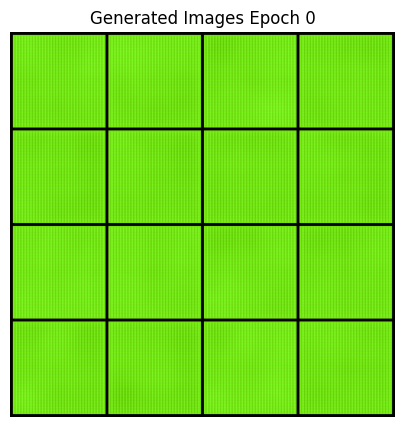

Epoch [1/200] Batch 0/57                   Loss D: 0.0443, Loss G: 3.1659
Epoch [1/200] Batch 50/57                   Loss D: 0.0140, Loss G: 4.2815
Epoch [2/200] Batch 0/57                   Loss D: 0.0137, Loss G: 4.4314
Epoch [2/200] Batch 50/57                   Loss D: 0.0343, Loss G: 3.6314
Epoch [3/200] Batch 0/57                   Loss D: 0.0219, Loss G: 4.0249
Epoch [3/200] Batch 50/57                   Loss D: 0.4573, Loss G: 1.5013
Epoch [4/200] Batch 0/57                   Loss D: 0.4486, Loss G: 3.1330
Epoch [4/200] Batch 50/57                   Loss D: 0.3548, Loss G: 2.4344
Epoch [5/200] Batch 0/57                   Loss D: 0.4397, Loss G: 1.7533
Epoch [5/200] Batch 50/57                   Loss D: 0.2792, Loss G: 2.4106
Epoch [6/200] Batch 0/57                   Loss D: 0.3274, Loss G: 2.3149
Epoch [6/200] Batch 50/57                   Loss D: 0.3719, Loss G: 2.4046
Epoch [7/200] Batch 0/57                   Loss D: 0.5437, Loss G: 2.1116
Epoch [7/200] Batch 50/57       

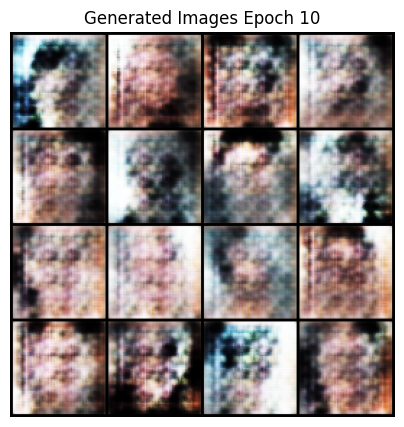

Epoch [11/200] Batch 0/57                   Loss D: 0.2987, Loss G: 3.0063
Epoch [11/200] Batch 50/57                   Loss D: 0.4707, Loss G: 2.8347
Epoch [12/200] Batch 0/57                   Loss D: 0.4177, Loss G: 2.4170
Epoch [12/200] Batch 50/57                   Loss D: 0.3110, Loss G: 2.4608
Epoch [13/200] Batch 0/57                   Loss D: 0.3362, Loss G: 1.2310
Epoch [13/200] Batch 50/57                   Loss D: 0.4326, Loss G: 2.5714
Epoch [14/200] Batch 0/57                   Loss D: 0.3847, Loss G: 2.2905
Epoch [14/200] Batch 50/57                   Loss D: 0.3666, Loss G: 2.7485
Epoch [15/200] Batch 0/57                   Loss D: 0.3231, Loss G: 2.6407
Epoch [15/200] Batch 50/57                   Loss D: 0.3971, Loss G: 2.0139
Epoch [16/200] Batch 0/57                   Loss D: 0.3939, Loss G: 1.9541
Epoch [16/200] Batch 50/57                   Loss D: 0.3480, Loss G: 2.1435
Epoch [17/200] Batch 0/57                   Loss D: 0.5014, Loss G: 1.4393
Epoch [17/200] Batc

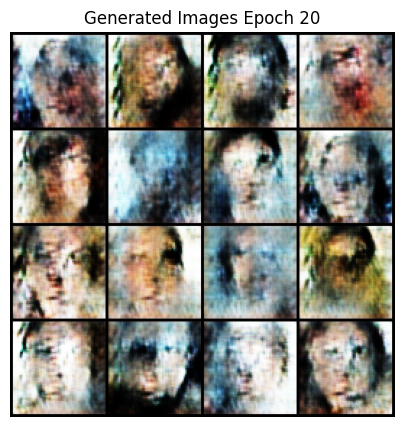

Epoch [21/200] Batch 0/57                   Loss D: 0.3932, Loss G: 3.7911
Epoch [21/200] Batch 50/57                   Loss D: 0.2575, Loss G: 3.9858
Epoch [22/200] Batch 0/57                   Loss D: 0.2698, Loss G: 2.9966
Epoch [22/200] Batch 50/57                   Loss D: 0.3248, Loss G: 3.0239
Epoch [23/200] Batch 0/57                   Loss D: 0.2200, Loss G: 2.9168
Epoch [23/200] Batch 50/57                   Loss D: 0.9907, Loss G: 2.7776
Epoch [24/200] Batch 0/57                   Loss D: 0.2729, Loss G: 2.6356
Epoch [24/200] Batch 50/57                   Loss D: 0.2505, Loss G: 2.3392
Epoch [25/200] Batch 0/57                   Loss D: 0.4820, Loss G: 4.6430
Epoch [25/200] Batch 50/57                   Loss D: 0.4955, Loss G: 5.0784
Epoch [26/200] Batch 0/57                   Loss D: 0.3205, Loss G: 4.6927
Epoch [26/200] Batch 50/57                   Loss D: 0.5863, Loss G: 5.2299
Epoch [27/200] Batch 0/57                   Loss D: 0.3150, Loss G: 3.4332
Epoch [27/200] Batc

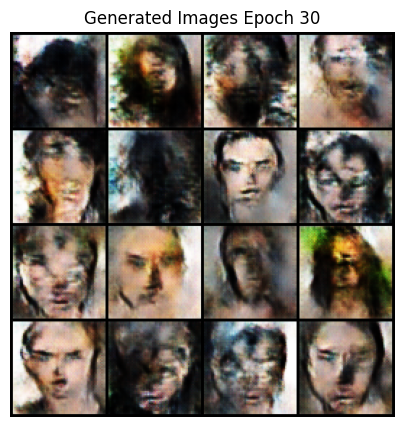

Epoch [31/200] Batch 0/57                   Loss D: 0.3397, Loss G: 2.1091
Epoch [31/200] Batch 50/57                   Loss D: 0.3077, Loss G: 4.4736
Epoch [32/200] Batch 0/57                   Loss D: 0.4906, Loss G: 5.4802


In [ ]:
print("Starting Training Loop...")

# Explicitly set models to train mode at the start
gen.train()
disc.train()

img_list = []
G_losses = []
D_losses = []

for epoch in range(NUM_EPOCHS):
    for batch_idx, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        batch_size = real_images.shape[0]

        ### 1. Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        disc.zero_grad()
        
        # Train on REAL images
        label_real = torch.ones(batch_size).to(device) # Labels = 1
        output_real = disc(real_images).reshape(-1)
        loss_disc_real = criterion(output_real, label_real)
        
        # Train on FAKE images
        noise = torch.randn(batch_size, Z_DIM, 1, 1).to(device)
        fake_images = gen(noise)
        label_fake = torch.zeros(batch_size).to(device) # Labels = 0
        
        # Detach fake_images so we don't calculate gradients for Gen yet
        output_fake = disc(fake_images.detach()).reshape(-1) 
        loss_disc_fake = criterion(output_fake, label_fake)
        
        # Total Discriminator Loss & Backprop
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        loss_disc.backward()
        opt_disc.step()

        ### 2. Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z)))
        gen.zero_grad()
        
        # We want the discriminator to believe these fakes are real (label=1)
        output = disc(fake_images).reshape(-1)
        loss_gen = criterion(output, label_real)
        
        loss_gen.backward()
        opt_gen.step()

        # Print stats
        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx}/{len(dataloader)} \
                  Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

    # Save images every 10 epochs
    if epoch % 10 == 0:
        #  Switch to eval mode for clean generation (uses fixed stats)
        gen.eval() 
        with torch.no_grad():
            fake = gen(fixed_noise)
            # Take top 16 images
            img_grid = vutils.make_grid(fake[:16], normalize=True, nrow=4)
            plt.figure(figsize=(5,5))
            plt.axis("off")
            plt.title(f"Generated Images Epoch {epoch}")
            plt.imshow(np.transpose(img_grid.cpu().numpy(), (1, 2, 0)))
            plt.show()
        
        #  Switch back to train mode for the next epoch
        gen.train()

print("Training Finished.")

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
LR = 0.0002            # Learning rate 
BETA1 = 0.5            # Beta1 for Adam 
BATCH_SIZE = 128       # Batch size
IMAGE_SIZE = 64        # 64x64 for better face quality
CHANNELS = 3           # Color images
Z_DIM = 100            # Latent vector size 
NUM_EPOCHS = 200       # Number of training epochs

Using device: cuda


In [ ]:
# specific folder path
#  images are in: ./my_faces_dataset/images/*.jpg
DATA_PATH = './dataset' 

# Create the directory if it doesn't exist 
if not os.path.exists(DATA_PATH):
    os.makedirs(os.path.join(DATA_PATH, 'my_faces_dataset'))
    print(f"Created folder {DATA_PATH}. Please put  images in the 'my_faces_dataset' subfolder!")

# Define transforms: Resize -> Tensor -> Normalize (-1 to 1)
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Load dataset
try:
    dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"Loaded {len(dataset)} images.")
except:
    print("No images found. Please ensure you have images in the folder structure: root/class/image.jpg")

Loaded 7219 images.


In [5]:
class Discriminator(nn.Module):
    def __init__(self, channels_img):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            nn.Conv2d(channels_img, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 32 x 32
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 16 x 16
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 8 x 8
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 4 x 4 -> Output: 1 (Probability)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)

In [6]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            # Input: Latent vector Z
            # reshape Z to (N, z_dim, 1, 1) happens in forward pass
            
            # ConvTranspose2d: (In, Out, Kernel, Stride, Padding)
            # Project Z -> 4x4
            nn.ConvTranspose2d(z_dim, 512, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            
            # 4x4 -> 8x8
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, channels_img, kernel_size=4, stride=2, padding=1),
            nn.Tanh() # Output: -1 to 1
        )

    def forward(self, x):
        return self.gen(x)

In [7]:
# Initialize weights function
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

# Create models
gen = Generator(Z_DIM, CHANNELS).to(device)
disc = Discriminator(CHANNELS).to(device)

# Apply weights
initialize_weights(gen)
initialize_weights(disc)

# Optimizers (using Adam with beta1=0.5 as requested)
opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(BETA1, 0.999))

# Loss function
criterion = nn.BCELoss()

# Fixed noise for visualizing progress
fixed_noise = torch.randn(32, Z_DIM, 1, 1).to(device)

Starting Training Loop...
Epoch [0/200] Batch 0/57                   Loss D: 0.6969, Loss G: 0.7988


c:\Users\HP\anaconda3\envs\sap_agent\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [0/200] Batch 50/57                   Loss D: 0.0560, Loss G: 2.9557


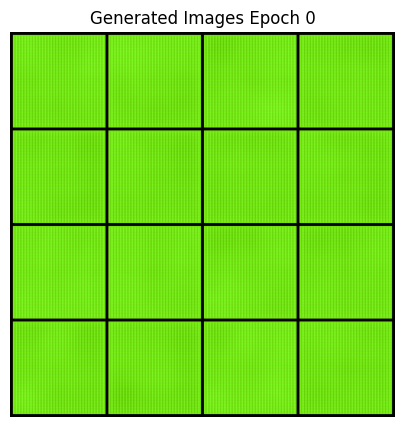

Epoch [1/200] Batch 0/57                   Loss D: 0.0443, Loss G: 3.1659
Epoch [1/200] Batch 50/57                   Loss D: 0.0140, Loss G: 4.2815
Epoch [2/200] Batch 0/57                   Loss D: 0.0137, Loss G: 4.4314
Epoch [2/200] Batch 50/57                   Loss D: 0.0343, Loss G: 3.6314
Epoch [3/200] Batch 0/57                   Loss D: 0.0219, Loss G: 4.0249
Epoch [3/200] Batch 50/57                   Loss D: 0.4573, Loss G: 1.5013
Epoch [4/200] Batch 0/57                   Loss D: 0.4486, Loss G: 3.1330
Epoch [4/200] Batch 50/57                   Loss D: 0.3548, Loss G: 2.4344
Epoch [5/200] Batch 0/57                   Loss D: 0.4397, Loss G: 1.7533
Epoch [5/200] Batch 50/57                   Loss D: 0.2792, Loss G: 2.4106
Epoch [6/200] Batch 0/57                   Loss D: 0.3274, Loss G: 2.3149
Epoch [6/200] Batch 50/57                   Loss D: 0.3719, Loss G: 2.4046
Epoch [7/200] Batch 0/57                   Loss D: 0.5437, Loss G: 2.1116
Epoch [7/200] Batch 50/57       

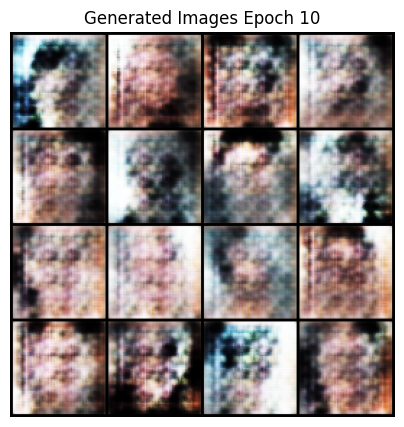

Epoch [11/200] Batch 0/57                   Loss D: 0.2987, Loss G: 3.0063
Epoch [11/200] Batch 50/57                   Loss D: 0.4707, Loss G: 2.8347
Epoch [12/200] Batch 0/57                   Loss D: 0.4177, Loss G: 2.4170
Epoch [12/200] Batch 50/57                   Loss D: 0.3110, Loss G: 2.4608
Epoch [13/200] Batch 0/57                   Loss D: 0.3362, Loss G: 1.2310
Epoch [13/200] Batch 50/57                   Loss D: 0.4326, Loss G: 2.5714
Epoch [14/200] Batch 0/57                   Loss D: 0.3847, Loss G: 2.2905
Epoch [14/200] Batch 50/57                   Loss D: 0.3666, Loss G: 2.7485
Epoch [15/200] Batch 0/57                   Loss D: 0.3231, Loss G: 2.6407
Epoch [15/200] Batch 50/57                   Loss D: 0.3971, Loss G: 2.0139
Epoch [16/200] Batch 0/57                   Loss D: 0.3939, Loss G: 1.9541
Epoch [16/200] Batch 50/57                   Loss D: 0.3480, Loss G: 2.1435
Epoch [17/200] Batch 0/57                   Loss D: 0.5014, Loss G: 1.4393
Epoch [17/200] Batc

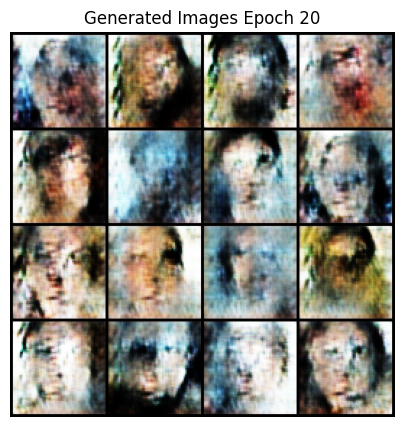

Epoch [21/200] Batch 0/57                   Loss D: 0.3932, Loss G: 3.7911
Epoch [21/200] Batch 50/57                   Loss D: 0.2575, Loss G: 3.9858
Epoch [22/200] Batch 0/57                   Loss D: 0.2698, Loss G: 2.9966
Epoch [22/200] Batch 50/57                   Loss D: 0.3248, Loss G: 3.0239
Epoch [23/200] Batch 0/57                   Loss D: 0.2200, Loss G: 2.9168
Epoch [23/200] Batch 50/57                   Loss D: 0.9907, Loss G: 2.7776
Epoch [24/200] Batch 0/57                   Loss D: 0.2729, Loss G: 2.6356
Epoch [24/200] Batch 50/57                   Loss D: 0.2505, Loss G: 2.3392
Epoch [25/200] Batch 0/57                   Loss D: 0.4820, Loss G: 4.6430
Epoch [25/200] Batch 50/57                   Loss D: 0.4955, Loss G: 5.0784
Epoch [26/200] Batch 0/57                   Loss D: 0.3205, Loss G: 4.6927
Epoch [26/200] Batch 50/57                   Loss D: 0.5863, Loss G: 5.2299
Epoch [27/200] Batch 0/57                   Loss D: 0.3150, Loss G: 3.4332
Epoch [27/200] Batc

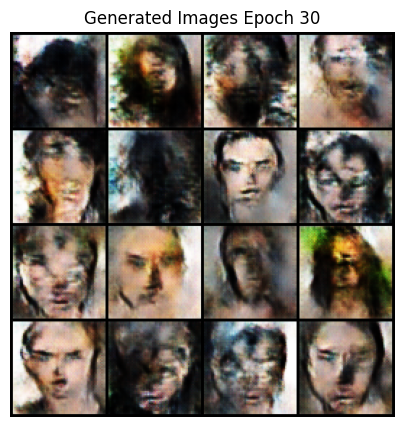

Epoch [31/200] Batch 0/57                   Loss D: 0.3397, Loss G: 2.1091
Epoch [31/200] Batch 50/57                   Loss D: 0.3077, Loss G: 4.4736
Epoch [32/200] Batch 0/57                   Loss D: 0.4906, Loss G: 5.4802


In [ ]:
print("Starting Training Loop...")

# Explicitly set models to train mode at the start
gen.train()
disc.train()

img_list = []
G_losses = []
D_losses = []

for epoch in range(NUM_EPOCHS):
    for batch_idx, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        batch_size = real_images.shape[0]

        ### 1. Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        disc.zero_grad()
        
        # Train on REAL images
        label_real = torch.ones(batch_size).to(device) # Labels = 1
        output_real = disc(real_images).reshape(-1)
        loss_disc_real = criterion(output_real, label_real)
        
        # Train on FAKE images
        noise = torch.randn(batch_size, Z_DIM, 1, 1).to(device)
        fake_images = gen(noise)
        label_fake = torch.zeros(batch_size).to(device) # Labels = 0
        
        # Detach fake_images so we don't calculate gradients for Gen yet
        output_fake = disc(fake_images.detach()).reshape(-1) 
        loss_disc_fake = criterion(output_fake, label_fake)
        
        # Total Discriminator Loss & Backprop
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        loss_disc.backward()
        opt_disc.step()

        ### 2. Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z)))
        gen.zero_grad()
        
        # We want the discriminator to believe these fakes are real (label=1)
        output = disc(fake_images).reshape(-1)
        loss_gen = criterion(output, label_real)
        
        loss_gen.backward()
        opt_gen.step()

        # Print stats
        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx}/{len(dataloader)} \
                  Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

    # Save images every 10 epochs
    if epoch % 10 == 0:
        #  Switch to eval mode for clean generation (uses fixed stats)
        gen.eval() 
        with torch.no_grad():
            fake = gen(fixed_noise)
            # Take top 16 images
            img_grid = vutils.make_grid(fake[:16], normalize=True, nrow=4)
            plt.figure(figsize=(5,5))
            plt.axis("off")
            plt.title(f"Generated Images Epoch {epoch}")
            plt.imshow(np.transpose(img_grid.cpu().numpy(), (1, 2, 0)))
            plt.show()
        
        #  Switch back to train mode for the next epoch
        gen.train()

print("Training Finished.")

In [ ]:
# Generate a single specific image
gen.eval() # Switch to eval mode for inference

with torch.no_grad():
    # Create random latent vector
    noise = torch.randn(1, Z_DIM, 1, 1).to(device)
    generated_img = gen(noise)
    
    # Process for display
    generated_img = generated_img.squeeze(0).cpu() # Remove batch dim, move to CPU
    
    # Normalize back from [-1, 1] to [0, 1]
    generated_img = (generated_img + 1) / 2.0 
    
    # Convert from (C, H, W) to (H, W, C) for Matplotlib
    generated_img = generated_img.permute(1, 2, 0).numpy()

    plt.imshow(generated_img)
    plt.axis('off')
    plt.title("Fake Human Face")
    plt.show()
    
    # Save model
    torch.save(gen.state_dict(), 'human_face_generator.pth')
    print("Model saved!")